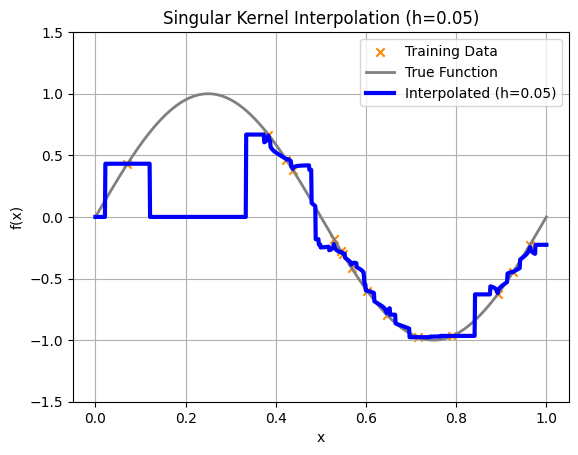

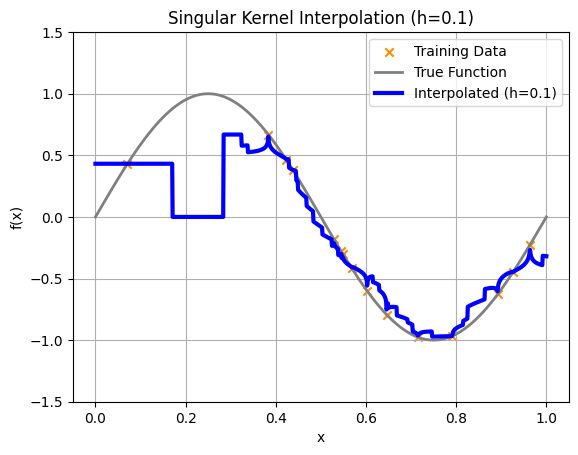

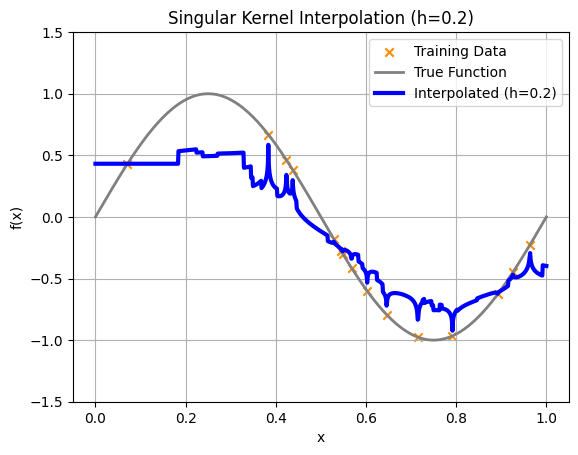

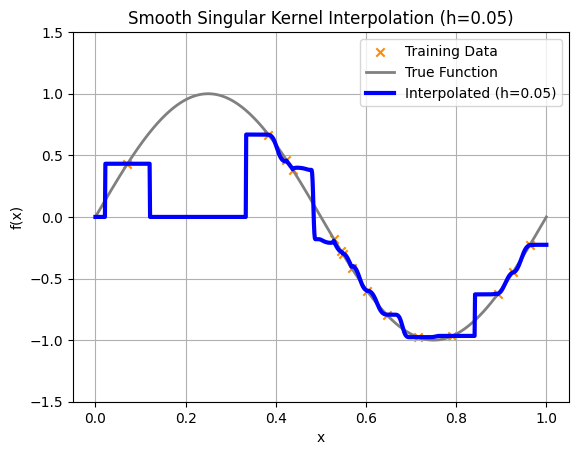

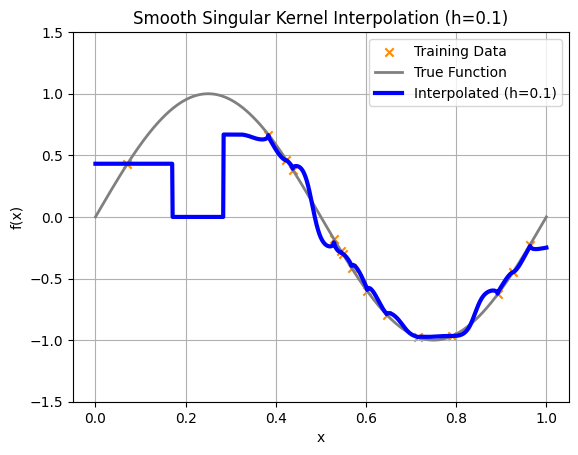

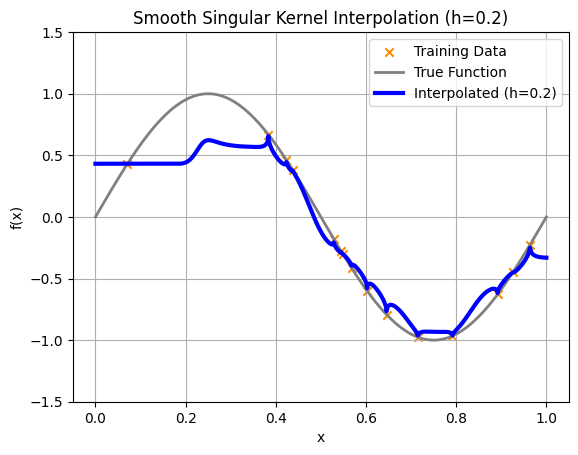

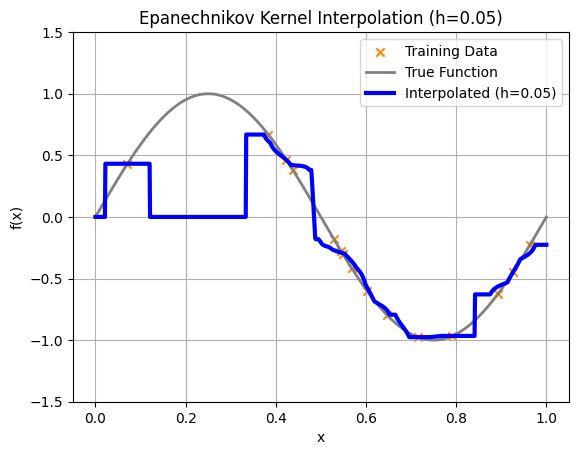

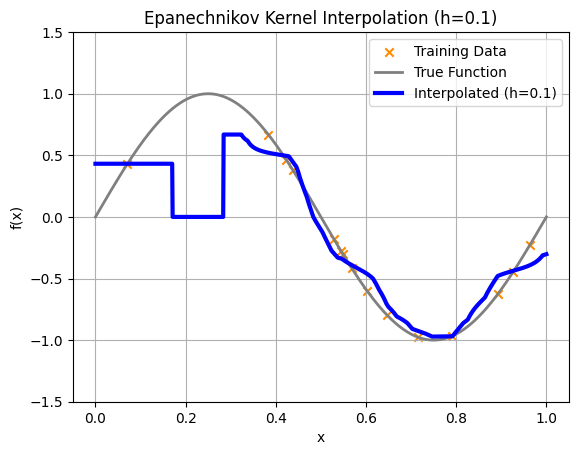

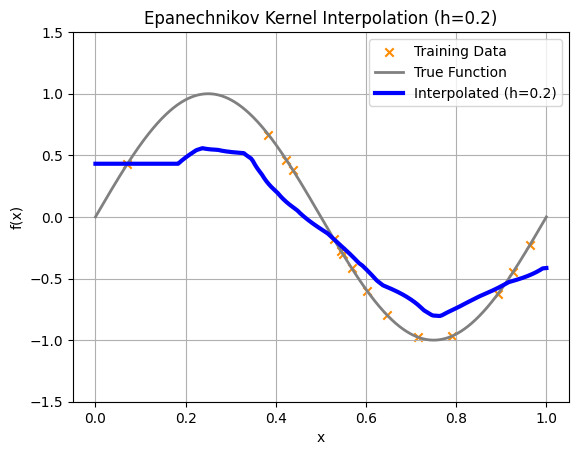

In [3]:
# -----------------------------------------
# Imports & Color Palette
# -----------------------------------------
import numpy as np
import matplotlib.pyplot as plt

color_palette = {
    "white": "#FFFFFF",
    "light_gray": "#D3D3D3",
    "gray": "#808080",
    "black": "#000000",
    "green": "#008000",
    "blue": "#0000FF",
    "light_blue": "#ADD8E6",
    "light_light_blue": "#E0FFFF",
    "yellow": "#FFFF00",
    "orange": "#FFA500",
    "dark_orange": "#FF8C00",
    "purple": "#800080",
}

np.random.seed(0)

# -----------------------------------------
# True Function & Data Generation
# -----------------------------------------
def true_function(x):
    return np.sin(2 * np.pi * x)

n = 15
X = np.sort(np.random.rand(n))
Y = true_function(X)

x_test = np.linspace(0, 1, 1000)

# -----------------------------------------
# Kernel Definitions
# -----------------------------------------
def kernel_singular(u, a):
    """
    Singular kernel with a = 0.49
    formula: K(u) = |u|^(-a)
    for |u| <= 1
    """
    norm_u = np.abs(u)
    return np.where(norm_u <= 1, norm_u**(-a), 0.0)

def kernel_smooth(u, a):
    """
    Smooth singular kernel with a = 0.49
    formula: K(u) = |u|^(-a) * (1 - |u|)^2
    for |u| <= 1
    """
    norm_u = np.abs(u)
    return np.where(norm_u <= 1, norm_u**(-a) * (1 - norm_u)**2, 0.0)

def kernel_epanechnikov(u):
    norm_u = np.abs(u)
    return np.where(norm_u <= 1, 0.75 * (1 - norm_u**2), 0.0)

# -----------------------------------------
# Interpolation Estimator
# -----------------------------------------
def interpolate(x_vals, X_train, Y_train, h, kernel_func, a=None):
    preds = []
    for x in x_vals:
        u = (x - X_train) / h
        weights = kernel_func(u, a) if a is not None else kernel_func(u)
        if np.any(x == X_train):
            preds.append(Y_train[np.argmin(np.abs(X_train - x))])
        elif np.sum(weights) == 0:
            preds.append(0.0)
        else:
            preds.append(np.sum(weights * Y_train) / np.sum(weights))
    return np.array(preds)

# -----------------------------------------
# Plotting Function
# -----------------------------------------
def plot_interpolation(kernel_name, kernel_func, a=None, hs=[0.05, 0.1, 0.2]):
    for h in hs:
        plt.figure()
        plt.scatter(X, Y, color=color_palette["dark_orange"], label="Training Data", marker='x')
        y_true = true_function(x_test)
        y_pred = interpolate(x_test, X, Y, h, kernel_func, a)
        plt.plot(x_test, y_true, label="True Function", color=color_palette["gray"], linewidth=2)
        plt.plot(x_test, y_pred, label=f"Interpolated (h={h})", color=color_palette["blue"], linewidth=3)
        plt.title(f"{kernel_name} Interpolation (h={h})")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.ylim(-1.5, 1.5)
        plt.legend()
        plt.grid(True)
        plt.show()

# -----------------------------------------
# Figure 1: Singular Kernel
# -----------------------------------------
plot_interpolation("Singular Kernel", kernel_singular, a=0.49, hs=[0.05, 0.1, 0.2])

# -----------------------------------------
# Figure 2: Smooth Interpolating Kernel
# -----------------------------------------
plot_interpolation("Smooth Singular Kernel", kernel_smooth, a=0.49, hs=[0.05, 0.1, 0.2])

# -----------------------------------------
# Figure 3: Epanechnikov Kernel (Non-Singular)
# -----------------------------------------
plot_interpolation("Epanechnikov Kernel", kernel_epanechnikov, a=None, hs=[0.05, 0.1, 0.2])